## This code is meant to be used only once!!
The code generates functions from a neural network with a certain architecture. Make sure to backup the data generated with this code (functions and weights)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pickle
import random
random.seed(a=1111)

In [2]:
# Network Architecture
ILS = 1 #Input layer size
NL, LS = 5, 10 # Number of hidden layers and their size

# Initialize weights
def init_w(ils=ILS, nl=NL, ls=LS):
    nu = [ils] + [ls] * nl
    w = []
    for l in range(nl):
        w.append([])
        for i in range(nu[l]):
            w[l].append([])
            for j in range(nu[l+1]):
                w[l][i].append(2*(np.random.uniform()-.5)**1)
    w.append([[(2*(np.random.uniform()-.5))**1 for i in range(nu[nl])]])
        
    return w

# Import weights
def import_w(file):
    with open(file, 'rb') as f:
        w = pickle.load(f)
    return w
    
# Compute output
def compute_output(invals, w, activation_fun):
    # Input layer
    cl = np.array(invals)
    # Hidden layers
    for l in range(len(w)-1):
        #print(len(w[l][0]))
        cl = np.array([np.sum([w[l][i][j]*cl[i] for i in range(len(cl))]) for j in range(len(w[l][0]))])
        if activation_fun=='tanh':
            cl = np.tanh(cl)
        elif activation_fun=='ReLU':
            cl=[cl_i if cl_i>0 else 0 for cl_i in cl]
        elif activation_fun=='leaky_ReLU':
            cl=[cl_i if cl_i>0 else 0.01*cl_i for cl_i in cl]
            
        
    return(np.sum([w[-1][i][0] * cl[i] for i in range(len(w[-1]))]))

In [3]:
NREP = 20 #Number of functions you want to generate
xmax=4;step=0.05 #limits of x and resolution step to generate functions

d_all = pd.DataFrame({'x1' : [], 'y': [], 'rep': []}) #initialize dataframe to for normalized functions
d_all_raw = pd.DataFrame({'x1' : [], 'y_raw': [], 'rep': []}) #initialize dataframe for non-normalized functions

activation_function='leaky_ReLU' #tanh, ReLU, leaky_ReLU . Activation functions for neural network

weights=[]
for rep in range(NREP):
    #Initialize NN and generate weights
    w = init_w(ils=ILS+1, nl=NL, ls=LS)
    weights.append(w)

    #initialize x and generate y values
    x1 = np.arange(-xmax, xmax, step)
    x1s, ys = [], []
    y = [compute_output([1, thisx1], w, activation_function) for thisx1 in x1]
    x1s=x1
    ys=y
    
    # Normalize functions
    ys = np.array(ys)
    ys_norm = (ys - min(ys)) / (max(ys) - min(ys) + 1e-15)

    #Save normalized functions to dataframes
    d = pd.DataFrame({'x1' : x1s, 'y' : ys_norm, 'rep': rep})
    d_all=pd.concat([d_all,d])
    
    #Save non-normalized version
    d_raw = pd.DataFrame({'x1' : x1s, 'y_raw' : ys, 'rep': rep})
    d_all_raw=pd.concat([d_all_raw,d_raw])

#Save weights to pickle and dataframes to csvs
save=False

if save==True:
    with open('../../data/generative_data/' + 'NN_weights_' + str(activation_function) + '_NREP_' + str(NREP) + '_ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) +'.pickle', 'wb') as f:
        pickle.dump(weights, f, protocol=None)

    d_all.to_csv('../../data/generative_data/' + 'NN_function_' + str(activation_function) + '_NREP_' + str(NREP) + '_ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '_res_' + str(step) + '_data.csv')
    d_all_raw.to_csv('../../data/generative_data/' + 'non_normalized_NN_function_' + str(activation_function) + '_NREP_' + str(NREP) + '_ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '_data.csv')

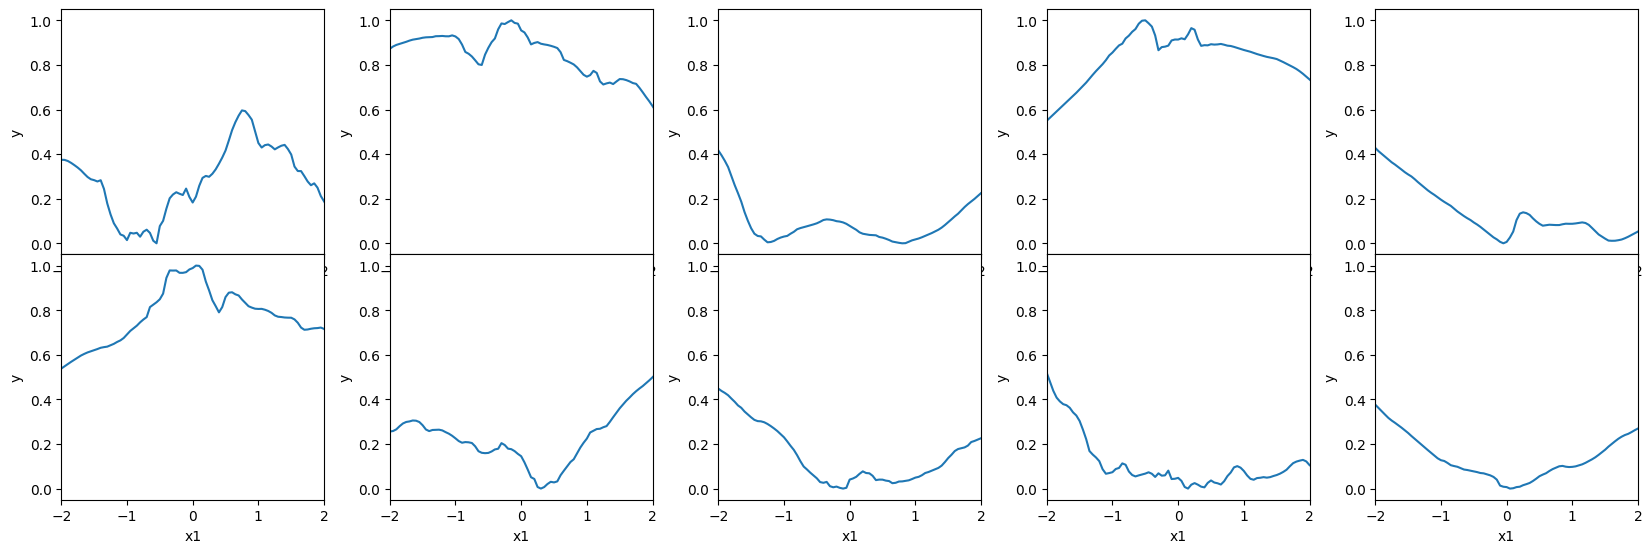

In [4]:
#PLOT -2,2

#Figure Size                                                                                                                                                                                                
cm = 1/2.54  # centimeters in inches                                                                                                                                                                        
width=45*cm;height=14*cm #Width and height of plots 
matplotlib.rcParams['figure.figsize'] = [width, height]

rows=2;cols=5
gs=gridspec.GridSpec(rows,cols)
gs.update(left=0.1,right=0.99,bottom=0.08,top=0.97,wspace=0.25,hspace=0.0)

#Plot train rank (-2,2)
h=0
for r in range(rows):
    for c in range(cols):
        ax_rc=plt.subplot(gs[r,c])
        d=d_all[d_all['rep']==h]
        ax_rc=sns.lineplot(data=d, x='x1', y='y')
        ax_rc.set_xlim(-2,2)
        h+=1
plt.savefig('../../results/seminal_data/' + 'NN_function_' + activation_function + '_' + 'ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '.png', dpi=300)

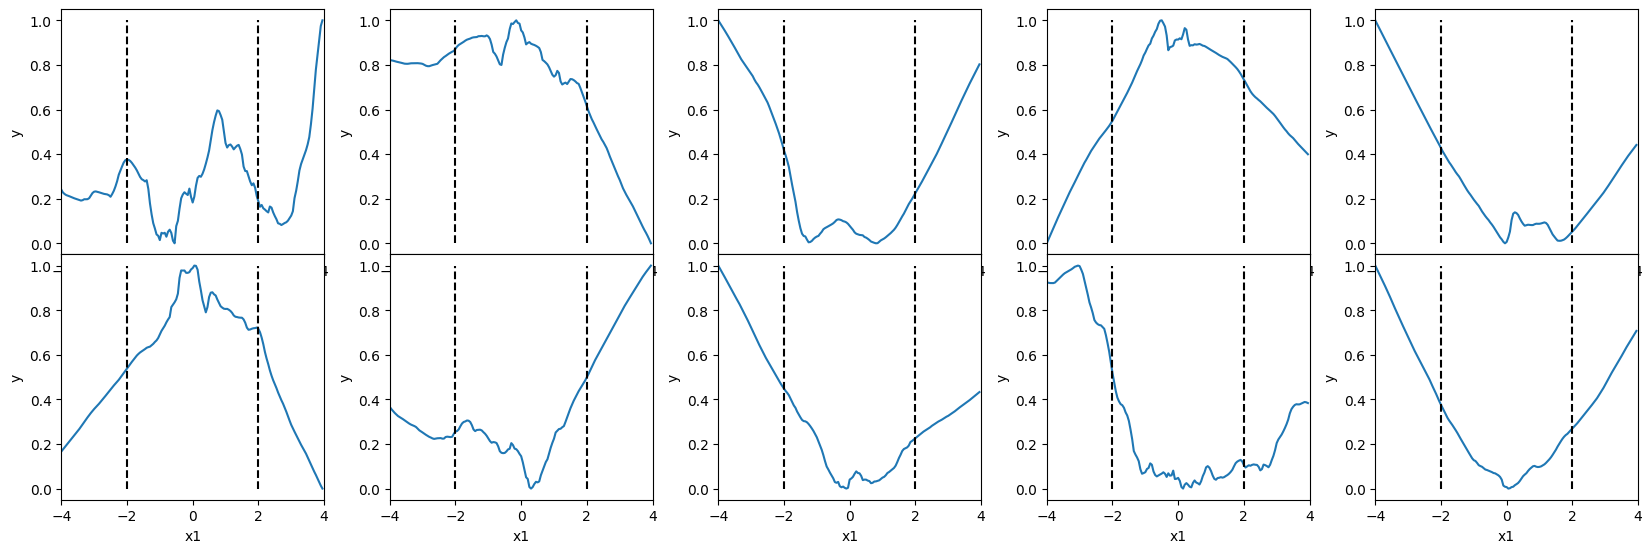

In [5]:
#PLOT FULL RANK (-4,4)

#Figure Size                                                                                                                                                                                                
cm = 1/2.54  # centimeters in inches                                                                                                                                                                        
width=45*cm;height=14*cm #Width and height of plots 
matplotlib.rcParams['figure.figsize'] = [width, height]

h=0
for r in range(rows):
    for c in range(cols):
        ax_rc=plt.subplot(gs[r,c])
        d=d_all[d_all['rep']==h]
        ax_rc=sns.lineplot(data=d, x='x1', y='y')
        ax_rc.vlines(x=[-2, 2], ymin=0, ymax=1, color='k',linestyle='--')
        ax_rc.set_xlim(-4,4)
        h+=1
plt.savefig('../../results/seminal_data/' + 'NN_function_full_rank_' + activation_function + '_' + 'ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '.png', dpi=300)